# **🏷️ Classification Pipeline 01**

**Dataset:**

- Breast Cancer Wisconsin dataset from sklearn, containing numerical features for binary classification.

**Pipeline Components:**

- `ColumnTransformer` for preprocessing:

  - `StandardScaler` applied to numerical features.

  - `OneHotEncoder` applied to categorical features

- `Pipeline` from sklearn.pipeline used to chain preprocessing and modeling steps.

**Model:**

- `LogisticRegression` (can be swapped with other classifiers).

**Hyperparameter Tuning:**

- `GridSearchCV` used for cross-validated hyperparameter optimization (e.g., tuning alpha in Ridge).

**Evaluation Metrics:**

- `Accuracy, Precision, Recall, F1-score, ROC AUC, Log Loss`.

**Visualization (Optional):**

- `Confusion Matrix, ROC Curve, Precision-Recall Curve`.

---
# **⬜ Import dependencies**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)

---
# **⬜ Load from sk-learn**

In [5]:
# Load dataset
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

In [4]:
# Simulate some categorical features
X['mean radius category'] = pd.cut(X['mean radius'], bins=3, labels=['small', 'medium', 'large'])

---
# **🟨 Train-test split**

In [6]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Identify feature types
num_features = X.select_dtypes(include='number').columns.tolist()
cat_features = X.select_dtypes(include='category', exclude='number').columns.tolist() + \
               X.select_dtypes(include='object').columns.tolist()

---
# **🟨 Column Transformer**

In [8]:
# Preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

---
# **🟨 Training Pipeline**

In [9]:
# Define pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=500))
])

In [10]:
# Grid search
param_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs']
}

In [11]:
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['mean '
                                                                          'radius',
                                                                          'mean '
                                                                          'texture',
                                                                          'mean '
                                                                          'perimeter',
                                                                          'mean '
                                                                          'area',
                                                                          'mean '
                                                                          'smoothness',
                                                                          'mean '
                                                                          'compactness',
                                                                          'mean '
                                                                          'concavity',
                                                                          'mean '
                                                                          'concave '
                                                                          'points',
                                                                          'mean '
                                                                          'symmetry',
                                                                          'mean '
                                                                          'fractal '
                                                                          'dimension',
                                                                          'radius '
                                                                          'error',
                                                                          'texture '
                                                                          'error',
                                                                          'perimeter '
                                                                          'e...
                                                                          'smoothness',
                                                                          'worst '
                                                                          'compactness',
                                                                          'worst '
                                                                          'concavity',
                                                                          'worst '
                                                                          'concave '
                                                                          'points',
                                                                          'worst '
                                                                          'symmetry',
                                                                          'worst '
                                                                          'fractal '
                                                                          'dimension']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         [])])),
                     

In [13]:
# Predictions
y_pred = grid_search.predict(X_test)
y_proba = grid_search.predict_proba(X_test)[:, 1]

---
# **🟩 Model Evaluation**

In [14]:
# Evaluation
print("🔍 Best Params:", grid_search.best_params_)
print("✅ Model Evaluation Metrics:")

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred),
    'ROC AUC': roc_auc_score(y_test, y_proba),
    'Log Loss': log_loss(y_test, y_proba)
}

for k, v in metrics.items():
    print(f"{k:20s}: {v:.4f}")

🔍 Best Params: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
✅ Model Evaluation Metrics:
Accuracy            : 0.9825
Precision           : 0.9726
Recall              : 1.0000
F1 Score            : 0.9861
ROC AUC             : 0.9984
Log Loss            : 0.0804


| Metric     | Description                                                                                 | When to Use                                               |
|------------|---------------------------------------------------------------------------------------------|-----------------------------------------------------------|
| `Accuracy`   | Overall ratio of correct predictions                                                        | When classes are balanced                                 |
| `Precision`  | Proportion of positive predictions that are correct                                        | When false positives are costly                           |
| `Recall`     | Proportion of actual positives that are correctly identified                               | When false negatives are costly                           |
| `F1 Score`   | Harmonic mean of precision and recall                                                     | When balance between precision and recall is needed     |
| `ROC AUC`    | Area under ROC curve measuring separability                                               | When you want to evaluate model's ranking ability         |
| `Log Loss`   | Penalizes false confident predictions, measures probabilistic predictions quality          | When well-calibrated probabilities are important         |


---
---
# **🟩 Model Visualization**

---
## **🟩 Confusion Matrix**

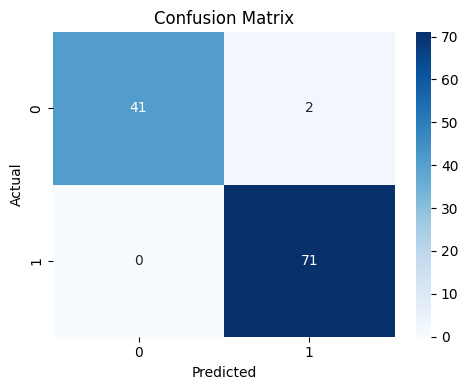

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

---
## **🟩 ROC Curve**

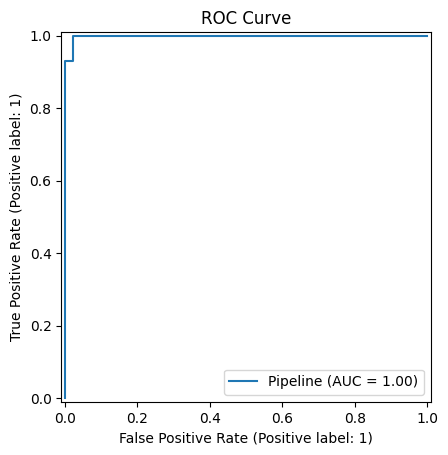

In [16]:
RocCurveDisplay.from_estimator(grid_search.best_estimator_, X_test, y_test)
plt.title("ROC Curve")
plt.show()

---
## **🟩 Precision-Recall Curve**

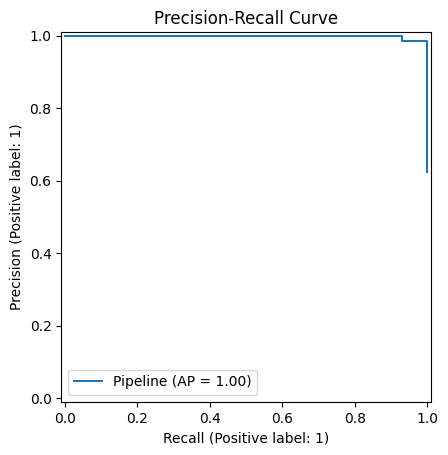

In [17]:
PrecisionRecallDisplay.from_estimator(grid_search.best_estimator_, X_test, y_test)
plt.title("Precision-Recall Curve")
plt.show()

---
---
---